# RQ4: Regression + SHAP — What Drives Developer Job Satisfaction?

**Research Question:** What professional, contextual, and AI-adoption factors most strongly drive developer job satisfaction, and do global feature importance rankings from tree ensemble models align with local SHAP-based attributions for individual high- and low-satisfaction predictions?

**Task:** Regression + Explainable AI (SHAP)  
**Target:** `JobSat` (job satisfaction score)  
**Models:** Random Forest, XGBoost, Gradient Boosting + SHAP TreeExplainer  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [58]:
!pip install shap --quiet

In [59]:
import os
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

ORGSIZE_MAP = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 2, '20 to 99 employees': 3,
    '100 to 499 employees': 4, '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6, '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8
}

AISENT_MAP = {'Very unfavorable': 1, 'Unfavorable': 2, 'Indifferent': 3,
              'Unsure': 3, 'Favorable': 4, 'Very favorable': 5}

AIACC_MAP = {'Highly distrust': 1, 'Somewhat distrust': 2,
             'Neither trust nor distrust': 3, 'Somewhat trust': 4, 'Highly trust': 5}

print('Imports OK')

Imports OK


## 1. Data Loading

In [60]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')
print('JobSat value counts:')
print(df['JobSat'].value_counts(dropna=False).head(15))

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)
JobSat value counts:
JobSat
NaN     22480
8.0      6964
7.0      5586
9.0      3595
6.0      3226
10.0     2921
5.0      1894
3.0       810
4.0       802
2.0       438
0.0       242
1.0       165
Name: count, dtype: int64


## 2. Target & Feature Engineering

In [61]:
# Filter: employed professional developers
df_emp = df[
    df['MainBranch'].str.contains('developer', case=False, na=False) |
    (df['MainBranch'] == 'I am a developer by profession')
].copy()

# Target: JobSat numeric
df_emp['JobSat_num'] = pd.to_numeric(df_emp['JobSat'], errors='coerce')
df_emp = df_emp.dropna(subset=['JobSat_num']).copy()
print(f'Rows after JobSat filter: {df_emp.shape[0]}')
print(f'JobSat range: {df_emp["JobSat_num"].min():.0f} – {df_emp["JobSat_num"].max():.0f}')

# Numeric conversions
df_emp['YearsCode']   = pd.to_numeric(df_emp['YearsCode'], errors='coerce')
df_emp['WorkExp']     = pd.to_numeric(df_emp['WorkExp'],   errors='coerce')
df_emp['OrgSize_num'] = df_emp['OrgSize'].map(ORGSIZE_MAP)
df_emp['AISent_num']  = df_emp['AISent'].map(AISENT_MAP)
df_emp['AIAcc_num']   = df_emp['AIAcc'].map(AIACC_MAP)
df_emp['AI_User']     = df_emp['AISelect'].apply(
    lambda x: 1 if isinstance(x, str) and x.startswith('Yes') else
              (0 if isinstance(x, str) and 'No' in x else np.nan)
)

# Salary feature (log-transformed, filter outliers)
df_emp['ConvertedCompYearly'] = pd.to_numeric(df_emp['ConvertedCompYearly'], errors='coerce')
df_emp['Comp_log'] = np.where(
    (df_emp['ConvertedCompYearly'] > 0) & (df_emp['ConvertedCompYearly'] < 1_000_000),
    np.log1p(df_emp['ConvertedCompYearly']), np.nan
)

# JobSatPoints: columns _1 through _16 except _12 and _15_TEXT
jobsat_cols_raw = [f'JobSatPoints_{i}' for i in [1,2,3,4,5,6,7,8,9,10,11,13,14,15,16]]
jobsat_cols_raw = [c for c in jobsat_cols_raw if c in df_emp.columns]
print(f'JobSatPoints columns found: {jobsat_cols_raw}')

MAX_RANK = 16
jobsat_reversed = {}
for col in jobsat_cols_raw:
    df_emp[col] = pd.to_numeric(df_emp[col], errors='coerce')
    rev_col = col + '_rev'
    df_emp[rev_col] = (MAX_RANK + 1) - df_emp[col]
    jobsat_reversed[col] = rev_col

JOBSAT_REV_COLS = list(jobsat_reversed.values())

NUMERIC_FEATURES = JOBSAT_REV_COLS + ['AISent_num', 'AIAcc_num', 'AI_User',
                                       'YearsCode', 'WorkExp', 'Comp_log', 'OrgSize_num']
CAT_FEATURES     = ['RemoteWork', 'Employment']

for col in CAT_FEATURES:
    df_emp[col] = df_emp[col].fillna('Unknown')

X = df_emp[NUMERIC_FEATURES + CAT_FEATURES].copy()
y = df_emp['JobSat_num'].copy()

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')

Rows after JobSat filter: 26643
JobSat range: 0 – 10
JobSatPoints columns found: ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16']
Features: 22 | Samples: 26643


## 3. Exploratory Data Analysis

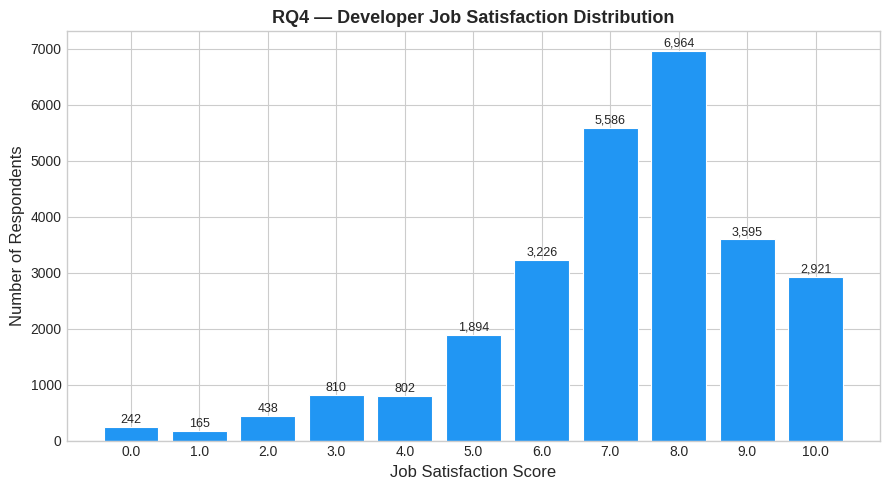

Saved figure: /kaggle/working/rq4_jobsat_distribution.pdf


In [62]:
val_counts = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(val_counts.index.astype(str), val_counts.values,
              color=PALETTE[0], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, val_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Job Satisfaction Score', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_title('RQ4 — Developer Job Satisfaction Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq4_jobsat_distribution.pdf')
plt.show()

## 4. Preprocessing Pipeline & Train/Test Split

In [63]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', cat_transformer,     CAT_FEATURES)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (21314, 22) | Test: (5329, 22)


## 5. Model Training & Cross-Validation

In [64]:
models = {
    'Random Forest':      RandomForestRegressor(n_estimators=300, max_depth=12,
                                                random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':            XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                       random_state=RANDOM_STATE, verbosity=0),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=RANDOM_STATE)
}

cv_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}
importance_dict = {}

for name, reg in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', reg)])
    t0 = time.time()
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv_kf, scoring='r2')
    pipe.fit(X_train, y_train)
    train_time = round(time.time() - t0, 2)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)
    r2_val = r2_score(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'Model':        name,
        'RMSE':         round(rmse, 4),
        'MAE':          round(mean_absolute_error(y_test, y_pred), 4),
        'R2':           round(r2_val, 4),
        'CV_R2_Mean':   round(cv_r2.mean(), 4),
        'CV_R2_Std':    round(cv_r2.std(), 4),
        'Train_Time_s': train_time
    })
    print(f"{name}: R²={results[-1]['R2']}  RMSE={results[-1]['RMSE']}")

    # Feature importances
    model_step = pipe.named_steps['model']
    if hasattr(model_step, 'feature_importances_'):
        importance_dict[name] = model_step.feature_importances_

results_df = pd.DataFrame(results)
results_df

Random Forest: R²=0.0501  RMSE=1.9134
XGBoost: R²=0.0387  RMSE=1.9249
Gradient Boosting: R²=0.0533  RMSE=1.9101


,Model,RMSE,MAE,R2,CV_R2_Mean,CV_R2_Std,Train_Time_s
0,Random Forest,1.9134,1.4491,0.0501,0.0677,0.0103,49.64
1,XGBoost,1.9249,1.4589,0.0387,0.0541,0.0090,3.08
2,Gradient Boosting,1.9101,1.4472,0.0533,0.0720,0.0084,56.37


In [65]:
# Recover feature names after OHE
best_pipe = fitted_models['XGBoost']
cat_encoder = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(cat_encoder.get_feature_names_out(CAT_FEATURES))
ALL_FEATURE_NAMES = NUMERIC_FEATURES + cat_feature_names
print(f'Total features after encoding: {len(ALL_FEATURE_NAMES)}')

Total features after encoding: 30


## 6. Publication-Ready Figures

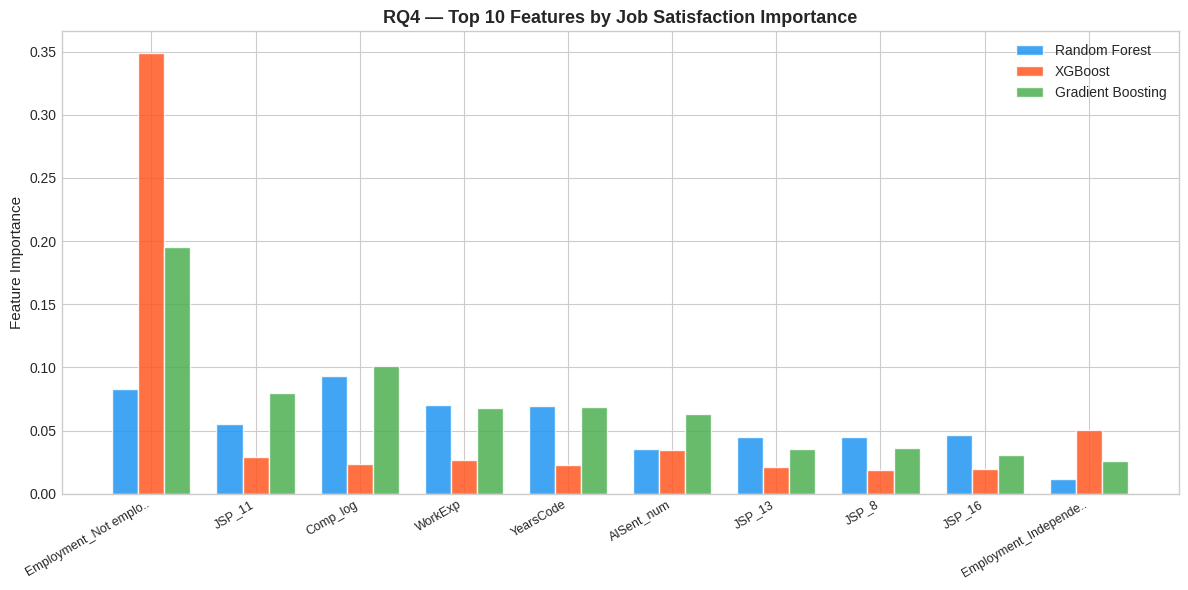

Saved figure: /kaggle/working/rq4_feature_importance_grouped_bar.pdf


In [66]:
# Feature importance grouped bar chart (top 10 by mean rank)
import_df = pd.DataFrame(importance_dict, index=ALL_FEATURE_NAMES[:len(list(importance_dict.values())[0])])

# Shorten feature names for display
def shorten_name(name):
    name = name.replace('JobSatPoints_', 'JSP_').replace('_rev', '').replace('RemoteWork_', 'Remote_')
    if len(name) > 22:
        name = name[:20] + '..'
    return name

import_df.index = [shorten_name(n) for n in import_df.index]
for col in import_df.columns:
    import_df[f'{col}_rank'] = import_df[col].rank(ascending=False)
import_df['mean_rank'] = import_df[[f'{c}_rank' for c in models]].mean(axis=1)
top10 = import_df.nsmallest(10, 'mean_rank')

x = np.arange(len(top10))
width = 0.25
cols_to_plot = list(models.keys())

fig, ax = plt.subplots(figsize=(12, 6))
for i, (col, color) in enumerate(zip(cols_to_plot, PALETTE)):
    ax.bar(x + i * width, top10[col], width, label=col, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(top10.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance', fontsize=11)
ax.set_title('RQ4 — Top 10 Features by Job Satisfaction Importance', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq4_feature_importance_grouped_bar.pdf')
plt.show()

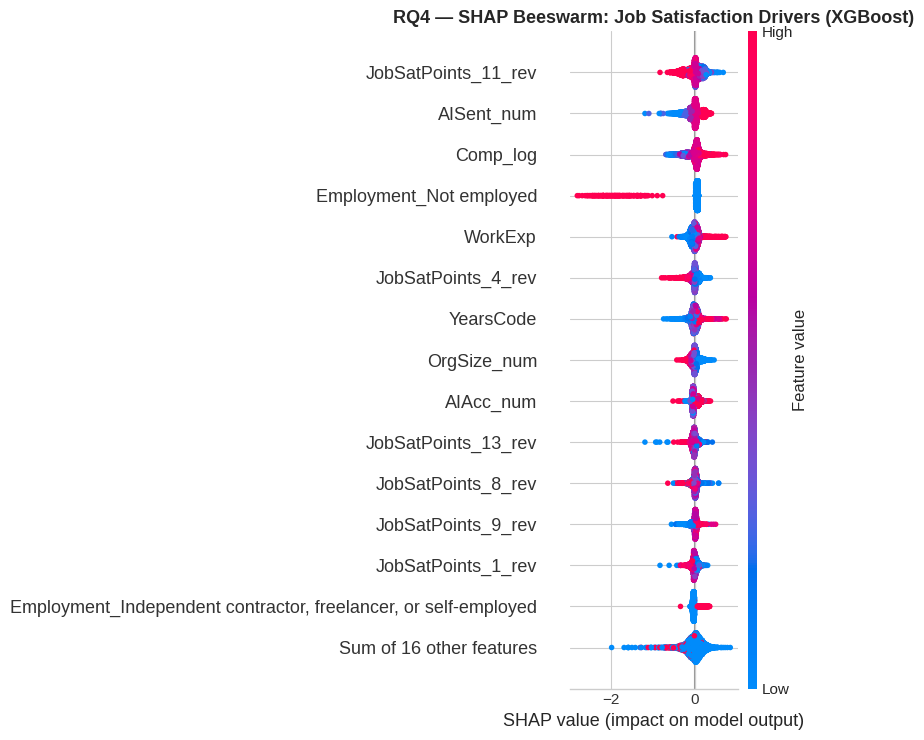

Saved figure: /kaggle/working/rq4_shap_beeswarm.pdf


In [67]:
# SHAP Beeswarm
xgb_pipe = fitted_models['XGBoost']
X_test_transformed = xgb_pipe.named_steps['preprocessor'].transform(X_test)
xgb_model = xgb_pipe.named_steps['model']

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer(X_test_transformed)
shap_vals.feature_names = ALL_FEATURE_NAMES[:X_test_transformed.shape[1]]

fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_vals, max_display=15, show=False)
plt.title('RQ4 — SHAP Beeswarm: Job Satisfaction Drivers (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq4_shap_beeswarm.pdf')
plt.show()

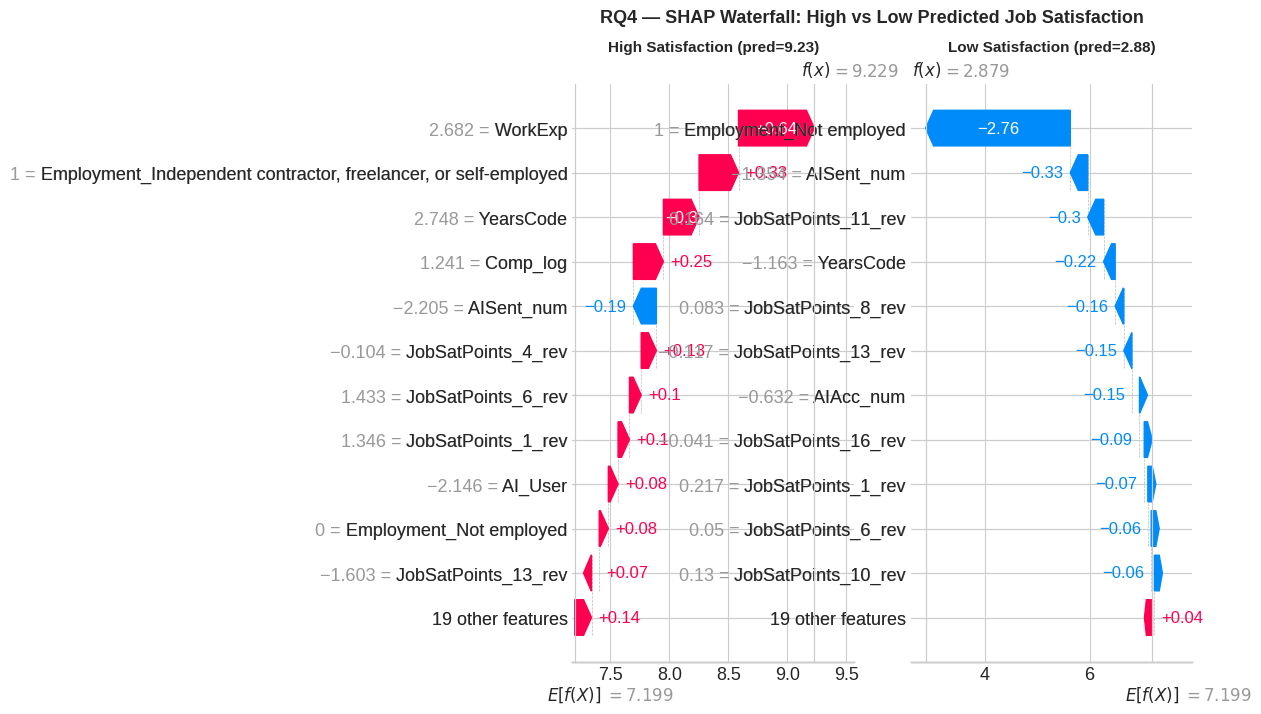

Saved figure: /kaggle/working/rq4_shap_waterfall_high_low.pdf


In [68]:
# SHAP Waterfall: highest vs lowest predicted JobSat
y_pred_xgb = xgb_pipe.predict(X_test)
high_idx = np.argmax(y_pred_xgb)
low_idx  = np.argmin(y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.plots.waterfall(shap_vals[high_idx], max_display=12, show=False)
axes[0].set_title(f'High Satisfaction (pred={y_pred_xgb[high_idx]:.2f})', fontsize=11, fontweight='bold')

plt.sca(axes[1])
shap.plots.waterfall(shap_vals[low_idx], max_display=12, show=False)
axes[1].set_title(f'Low Satisfaction (pred={y_pred_xgb[low_idx]:.2f})', fontsize=11, fontweight='bold')

fig.suptitle('RQ4 — SHAP Waterfall: High vs Low Predicted Job Satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq4_shap_waterfall_high_low.pdf')
plt.show()

## 7. Summary Tables

In [69]:
# Feature importance comparison table
feat_names_short = [shorten_name(n) for n in ALL_FEATURE_NAMES[:len(list(importance_dict.values())[0])]]
import_compare = pd.DataFrame({'Feature': feat_names_short})
for name in models:
    if name in importance_dict:
        imps = importance_dict[name]
        col = name.replace(' ', '_')
        import_compare[f'{col}_Importance'] = imps
        import_compare[f'{col}_Rank']       = pd.Series(imps).rank(ascending=False).astype(int).values

import_compare['Mean_Rank'] = import_compare[
    [f'{n.replace(" ", "_")}_Rank' for n in models if n in importance_dict]
].mean(axis=1).round(2)
import_compare = import_compare.sort_values('Mean_Rank')
save_table(import_compare, 'rq4_feature_importance_comparison.csv')
print(f'Feature importance table: {import_compare.shape}')

# Spearman rank correlation between models
from scipy.stats import spearmanr
rank_corr_rows = []
model_names = [n for n in models if n in importance_dict]
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a, b = model_names[i], model_names[j]
        rho, pval = spearmanr(importance_dict[a], importance_dict[b])
        rank_corr_rows.append({
            'Model_A': a, 'Model_B': b,
            'Spearman_rho': round(rho, 4),
            'p_value':      round(pval, 6)
        })
rank_corr_df = pd.DataFrame(rank_corr_rows)
save_table(rank_corr_df, 'rq4_importance_rank_correlation.csv')
rank_corr_df

Saved table:  /kaggle/working/rq4_feature_importance_comparison.csv
Feature importance table: (30, 8)
Saved table:  /kaggle/working/rq4_importance_rank_correlation.csv


,Model_A,Model_B,Spearman_rho,p_value
0,Random Forest,XGBoost,0.1600,0.398479
1,Random Forest,Gradient Boosting,0.8714,0.000000
2,XGBoost,Gradient Boosting,0.4403,0.014900


## 8. Conclusions

In [70]:
best_row = results_df.loc[results_df['R2'].idxmax()]
print('=' * 60)
print('RQ4 CONCLUSION')
print('=' * 60)
print(f'Best model:  {best_row["Model"]}')
print(f'  R²:        {best_row["R2"]}')
print(f'  RMSE:      {best_row["RMSE"]}')
print()
print('Output files saved to /kaggle/working/:')
print('  rq4_jobsat_distribution.pdf')
print('  rq4_feature_importance_grouped_bar.pdf')
print('  rq4_shap_beeswarm.pdf')
print('  rq4_shap_waterfall_high_low.pdf')
print('  rq4_feature_importance_comparison.csv')
print('  rq4_importance_rank_correlation.csv')

RQ4 CONCLUSION
Best model:  Gradient Boosting
  R²:        0.0533
  RMSE:      1.9101

Output files saved to /kaggle/working/:
  rq4_jobsat_distribution.pdf
  rq4_feature_importance_grouped_bar.pdf
  rq4_shap_beeswarm.pdf
  rq4_shap_waterfall_high_low.pdf
  rq4_feature_importance_comparison.csv
  rq4_importance_rank_correlation.csv
